<a href="https://colab.research.google.com/github/vedasri2511/DL-Assignment/blob/main/DL_Assign.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from tensorflow.keras.datasets import cifar10

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step


would like to change the noise, hidden layer learning rate, feature dropout for each layer,

**FULLY CONNECTED NEURAL NETWORK**

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.optimizers import SGD, Adam, RMSprop, Adagrad

In [ ]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [ ]:
pip install torch torchvision

**MLP**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False)

class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(32*32*3, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

model = MLP().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 10

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for images, labels in trainloader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(trainloader):.4f}")

model.eval()
correct = 0
total = 0
with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

100%|██████████| 170M/170M [00:06<00:00, 25.9MB/s]


Epoch [1/10], Loss: 1.6329
Epoch [2/10], Loss: 1.4125
Epoch [3/10], Loss: 1.2965
Epoch [4/10], Loss: 1.2015
Epoch [5/10], Loss: 1.1173
Epoch [6/10], Loss: 1.0408
Epoch [7/10], Loss: 0.9674
Epoch [8/10], Loss: 0.8897
Epoch [9/10], Loss: 0.8108
Epoch [10/10], Loss: 0.7402
Test Accuracy: 54.05%


**ANN**

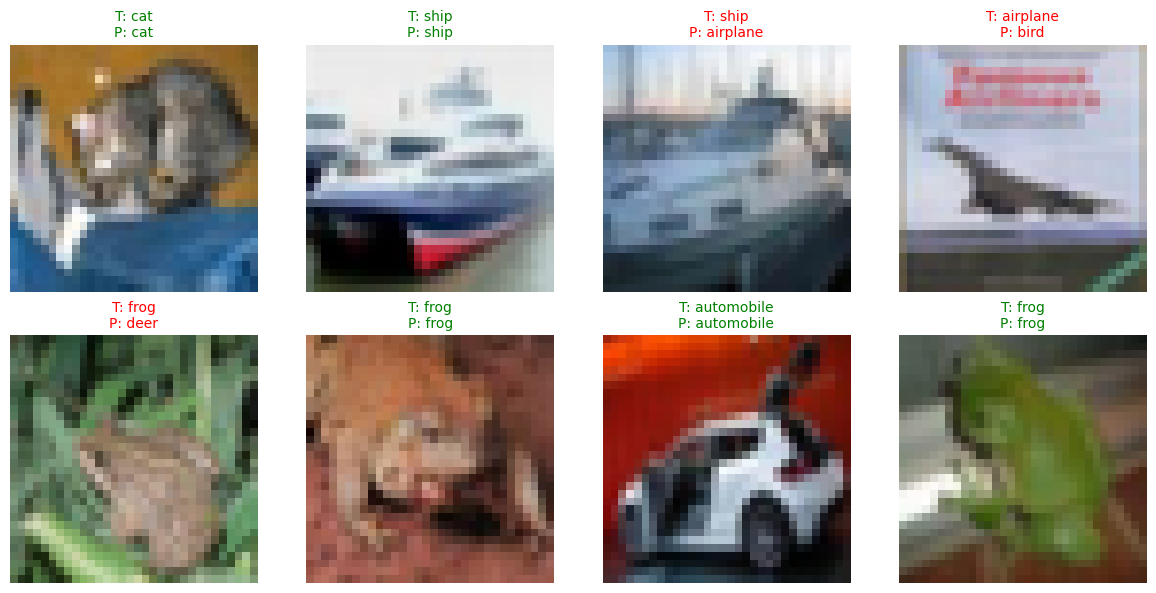

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

classes = ('airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck')

def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')

dataiter = iter(testloader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)

outputs = model(images)
_, predicted = torch.max(outputs, 1)

plt.figure(figsize=(12,6))
for i in range(8):
    plt.subplot(2,4,i+1)
    imshow(images[i].cpu())
    color = "green" if predicted[i] == labels[i] else "red"
    plt.title(
        f"T: {classes[labels[i]]}\nP: {classes[predicted[i]]}",
        color=color,
        fontsize=10
    )

plt.tight_layout()
plt.show()

In [ ]:
# show more samples to find some correct ANN predictions
for i in range(50):
    if ann_pred[i] == labels[i]:
        print("Correct at index:", i)

NameError: name 'ann_pred' is not defined

**CNN**

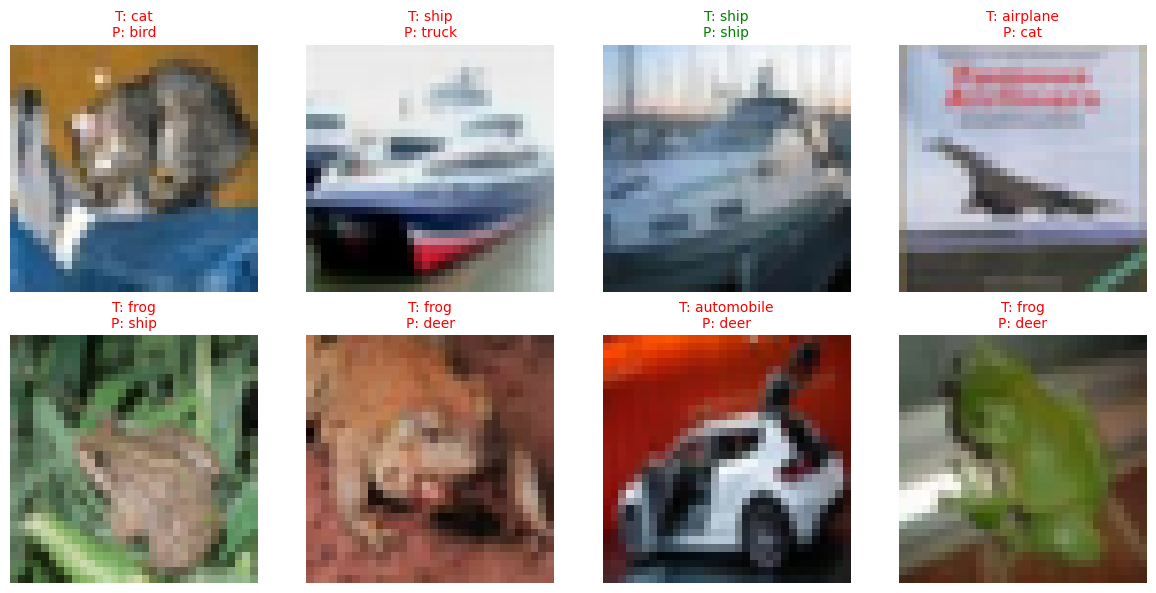

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

classes = ('airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck')

def imshow(img):
    img = img / 2 + 0.5
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.axis('off')

dataiter = iter(testloader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)

cnn_model = SimpleCNN().to(device)
outputs = cnn_model(images)
_, predicted = torch.max(outputs, 1)

plt.figure(figsize=(12,6))
for i in range(8):
    plt.subplot(2,4,i+1)
    imshow(images[i].cpu())
    color = "green" if predicted[i] == labels[i] else "red"
    plt.title(f"T: {classes[labels[i]]}\nP: {classes[predicted[i]]}",
              color=color, fontsize=10)

plt.tight_layout()
plt.show()

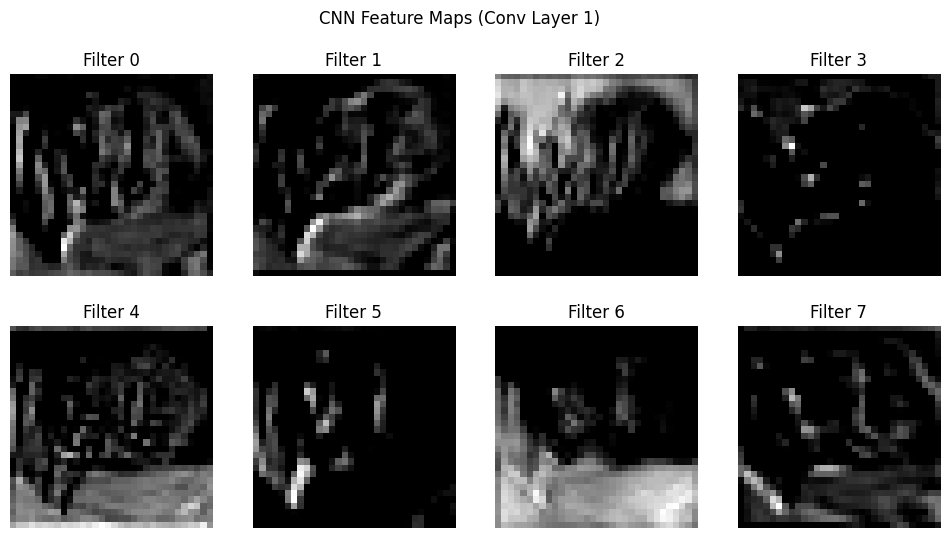

In [ ]:
with torch.no_grad():
    feature_maps = cnn_model.relu(cnn_model.conv1(images[0:1]))

plt.figure(figsize=(12,6))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(feature_maps[0,i].cpu(), cmap='gray')
    plt.axis('off')
    plt.title(f"Filter {i}")

plt.suptitle("CNN Feature Maps (Conv Layer 1)")
plt.show()

**OBSERVATION**

Edges


Corners

Texture patterns
→ Proof that CNN learns spatial features

**ANN VS CNN**

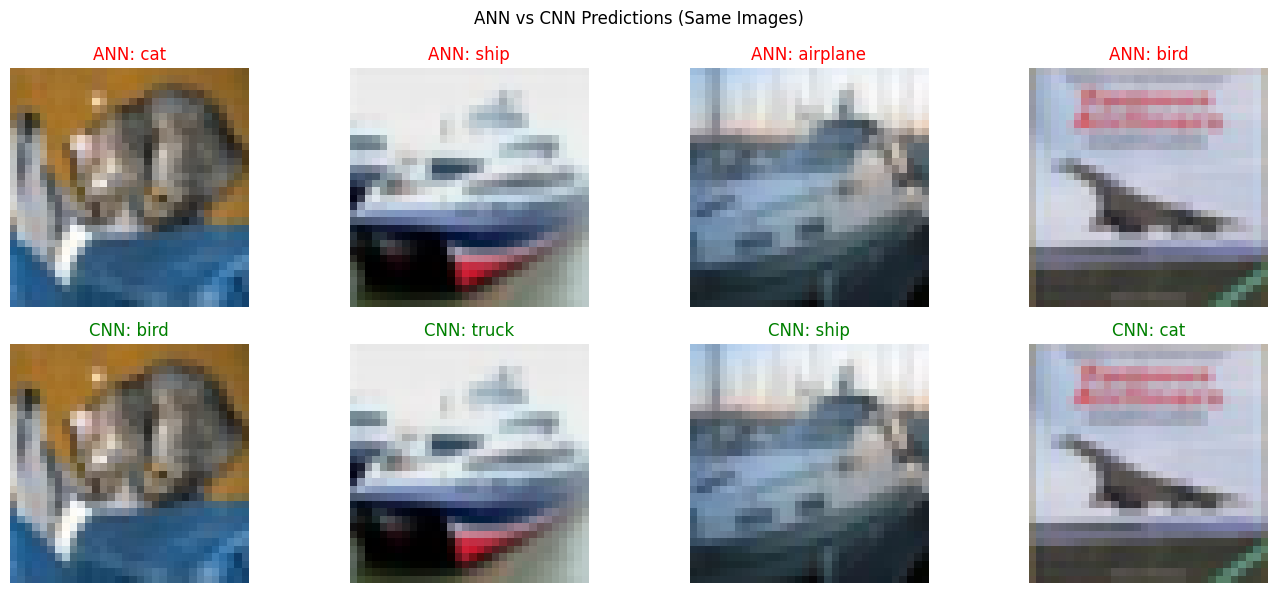

In [ ]:
ann_outputs = model(images)
_, ann_pred = torch.max(ann_outputs, 1)

cnn_outputs = cnn_model(images)
_, cnn_pred = torch.max(cnn_outputs, 1)

plt.figure(figsize=(14,6))

for i in range(4):
    plt.subplot(2,4,i+1)
    imshow(images[i].cpu())
    plt.title(f"ANN: {classes[ann_pred[i]]}", color='red')

    plt.subplot(2,4,i+5)
    imshow(images[i].cpu())
    plt.title(f"CNN: {classes[cnn_pred[i]]}", color='green')

plt.suptitle("ANN vs CNN Predictions (Same Images)")
plt.tight_layout()
plt.show()

actual

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5),(0.5,0.5,0.5))
])

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)

trainloader = torch.utils.data.DataLoader(trainset, batch_size=128, shuffle=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=128, shuffle=False)

classes = ('airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck')

100%|██████████| 170M/170M [02:33<00:00, 1.11MB/s]


In [ ]:
#ann mlp model
class ANN(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(32*32*3, 512)
        self.fc2 = nn.Linear(512, 256)
        self.fc3 = nn.Linear(256, 10)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = x.view(x.size(0), -1)   # FLATTEN IMAGE
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.fc3(x)
        return x

ann_model = ANN().to(device)

In [ ]:
#cnn model
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.pool = nn.MaxPool2d(2,2)
        self.relu = nn.ReLU()
        self.fc1 = nn.Linear(64*8*8, 256)
        self.fc2 = nn.Linear(256, 10)

    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool(x)
        x = self.relu(self.conv2(x))
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

cnn_model = CNN().to(device)

In [ ]:
#training for both ann and cnn
def train_model(model, epochs=5):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for images, labels in trainloader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}, Loss: {total_loss/len(trainloader):.4f}")

In [ ]:
print("Training ANN")
train_model(ann_model)

print("\nTraining CNN")
train_model(cnn_model)

Training ANN
Epoch 1, Loss: 1.6329
Epoch 2, Loss: 1.4110
Epoch 3, Loss: 1.2933
Epoch 4, Loss: 1.1973
Epoch 5, Loss: 1.1114

Training CNN
Epoch 1, Loss: 1.3938
Epoch 2, Loss: 0.9967
Epoch 3, Loss: 0.8393
Epoch 4, Loss: 0.7204
Epoch 5, Loss: 0.6188


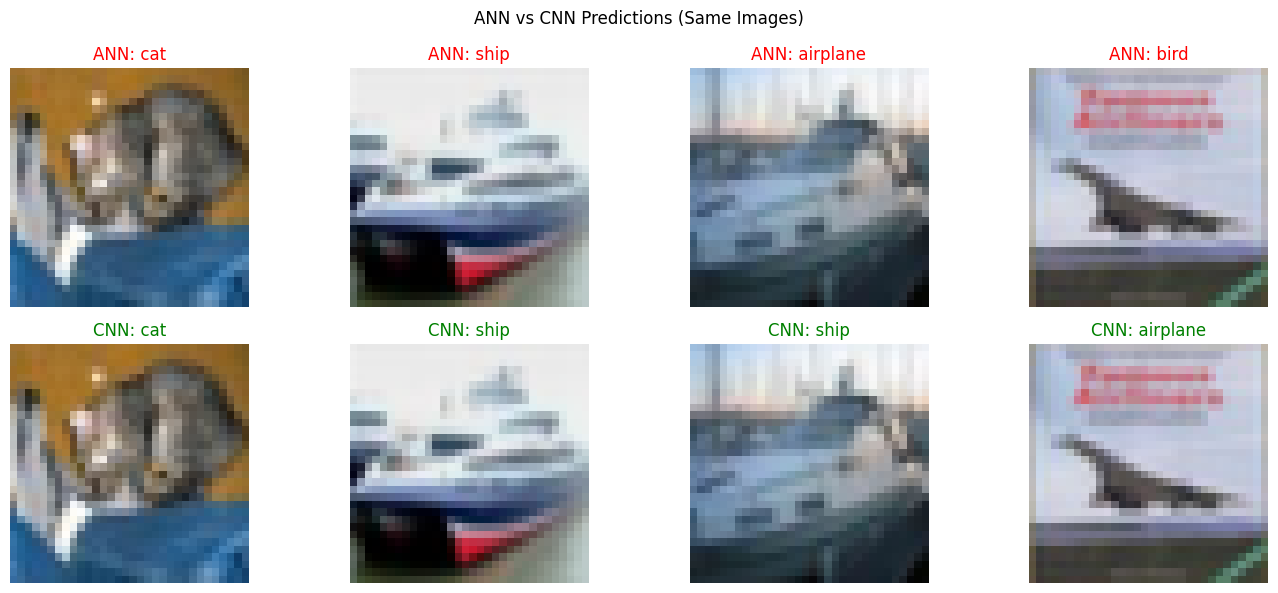

In [ ]:
def imshow(img):
    img = img / 2 + 0.5
    npimg = img.cpu().numpy()
    plt.imshow(np.transpose(npimg, (1,2,0)))
    plt.axis('off')

dataiter = iter(testloader)
images, labels = next(dataiter)
images, labels = images.to(device), labels.to(device)

ann_out = ann_model(images)
cnn_out = cnn_model(images)

_, ann_pred = torch.max(ann_out, 1)
_, cnn_pred = torch.max(cnn_out, 1)

plt.figure(figsize=(14,6))

for i in range(4):
    plt.subplot(2,4,i+1)
    imshow(images[i])
    plt.title(f"ANN: {classes[ann_pred[i]]}", color='red')

    plt.subplot(2,4,i+5)
    imshow(images[i])
    plt.title(f"CNN: {classes[cnn_pred[i]]}", color='green')

plt.suptitle("ANN vs CNN Predictions (Same Images)")
plt.tight_layout()
plt.show()

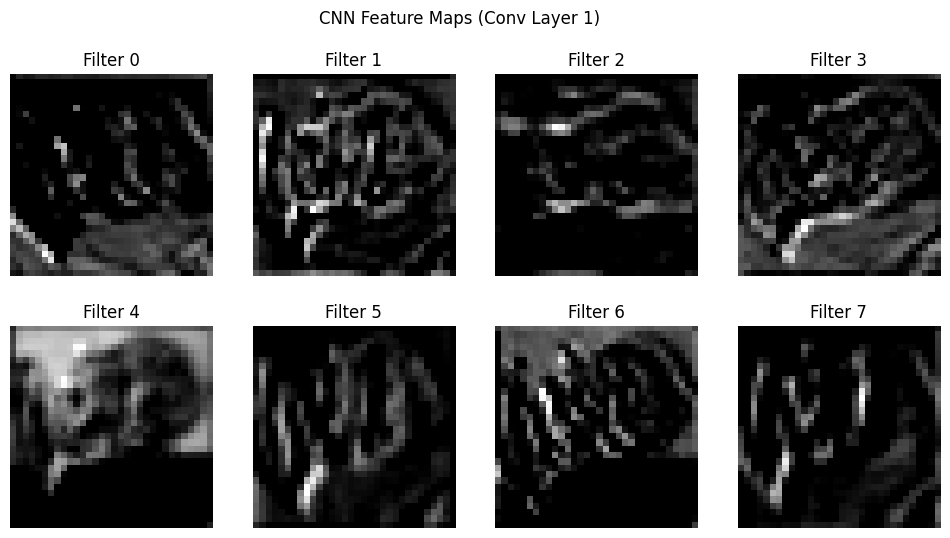

In [ ]:
with torch.no_grad():
    feature_maps = cnn_model.relu(cnn_model.conv1(images[0:1]))

plt.figure(figsize=(12,6))
for i in range(8):
    plt.subplot(2,4,i+1)
    plt.imshow(feature_maps[0,i].cpu(), cmap='gray')
    plt.axis('off')
    plt.title(f"Filter {i}")

plt.suptitle("CNN Feature Maps (Conv Layer 1)")
plt.show()

Filter